# Zomato Dataset Analysis

### Goal
Analyze restaurant and review data to extract insights on ratings, cuisines, location preferences, and factors affecting ratings, and translate the findings into concrete recommendations for an Alfido Tech–style platform. Save generated images and predictive models into separate dedicated folders (`images/` and `models/`).


## 1. Data Cleaning
- Loading raw dataset (`zomato.csv`).
- Handling text fields (stripping extra spaces, standardizing formatting).
- Handling corrupted/shifted text rows.
- Removing duplicates.
- Currency conversions & numeric parsing (`approx_cost(for two people)`).
- Rating column cleaning (`rate` -> numeric float).
- Handling missing values.
- Saving cleaned dataset to `models/cleaned_zomato.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
from wordcloud import WordCloud
from collections import Counter

# Create directories for saving images and models
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Set display options & visualization style
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

# Load raw dataset
df_raw = pd.read_csv("zomato.csv")
print("Raw Dataset Shape:", df_raw.shape)
df_raw.head()


Raw Dataset Shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [2]:
# Check initial missing values & data types
print("Initial Missing Values Per Column:")
print(df_raw.isnull().sum())


Initial Missing Values Per Column:
address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64


In [3]:
# 1. Filter corrupted / shifted rows (keeping valid categorical records)
valid_mask = df_raw['online_order'].isin(['Yes', 'No']) & df_raw['book_table'].isin(['Yes', 'No'])
df = df_raw[valid_mask].copy()

# 2. Remove duplicate records
initial_len = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_len - len(df)} duplicate records. Cleaned Dataset Shape: {df.shape}")

# 3. Clean Text Fields (trim whitespace, handle string columns)
text_cols = ['name', 'address', 'location', 'rest_type', 'cuisines', 'dish_liked', 'listed_in(type)']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# 4. Currency Conversion & Clean Cost Field ('approx_cost(for two people)')
def clean_currency_cost(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').strip()
    try:
        return float(val_str)
    except ValueError:
        return np.nan

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(clean_currency_cost)

# 5. Clean Rating Column ('rate' -> float)
def clean_rate(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if val_str in ['NEW', '-', '']:
        return np.nan
    match = re.search(r'(\d+\.?\d*)\s*/\s*5', val_str)
    if match:
        return float(match.group(1))
    try:
        f = float(val_str)
        return f if 0 <= f <= 5 else np.nan
    except ValueError:
        return np.nan

df['rate_num'] = df['rate'].apply(clean_rate)

# 6. Clean Votes Column
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# 7. Save cleaned dataset to models folder
df.to_csv("models/cleaned_zomato.csv", index=False)
print("Cleaned dataset saved to 'models/cleaned_zomato.csv'.")

# Summary of cleaned dataset & missing values
print("\nMissing Values After Cleaning:")
print(df[['name', 'online_order', 'book_table', 'rate_num', 'votes', 'location', 'cuisines', 'approx_cost(for two people)']].isnull().sum())
df[['rate_num', 'votes', 'approx_cost(for two people)']].describe()


Removed 15315 duplicate records. Cleaned Dataset Shape: (36402, 13)


Cleaned dataset saved to 'models/cleaned_zomato.csv'.

Missing Values After Cleaning:
name                              0
online_order                      0
book_table                        0
rate_num                       5538
votes                             0
location                         14
cuisines                         33
approx_cost(for two people)     219
dtype: int64


,rate_num,votes,approx_cost(for two people)
count,30864.000000,36402.000000,36183.000000
mean,3.712050,309.295533,575.606417
std,0.443828,809.804216,446.887138
min,1.800000,0.000000,40.000000
25%,3.400000,10.000000,300.000000
50%,3.800000,54.000000,450.000000
75%,4.000000,239.000000,700.000000
max,4.900000,16832.000000,6000.000000


## 2. Explore Relationships
- **Cuisine vs Rating**: Top cuisines analysis & average rating by cuisine.
- **Location Hotspots**: Identifying top restaurant density, vote volume, and high-rating locations.
- **Price vs Rating**: Correlation between dining cost for two people and overall ratings across price tiers.


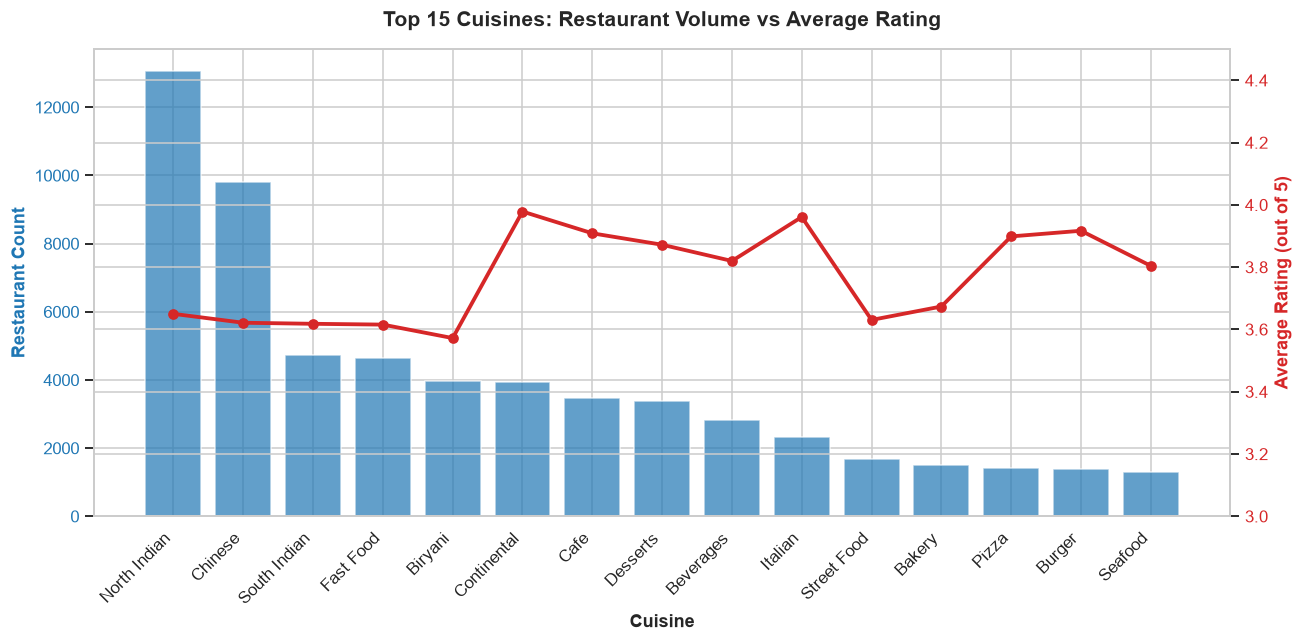

Saved visualization to 'images/cuisine_vs_rating.png'


In [4]:
# A. Cuisine vs Rating
cuisine_df = df.dropna(subset=['cuisines', 'rate_num']).copy()
cuisine_df['cuisine_list'] = cuisine_df['cuisines'].apply(lambda x: [c.strip() for c in str(x).split(',')])
cuisine_exploded = cuisine_df.explode('cuisine_list')

# Top 15 Most Popular Cuisines by Count and average rating
cuisine_stats = cuisine_exploded.groupby('cuisine_list').agg(
    restaurant_count=('name', 'count'),
    avg_rating=('rate_num', 'mean'),
    median_rating=('rate_num', 'median')
).reset_index()

top_15_cuisines = cuisine_stats.sort_values(by='restaurant_count', ascending=False).head(15)

# Visualization: Cuisine vs Rating
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Cuisine', fontweight='bold')
ax1.set_ylabel('Restaurant Count', color=color, fontweight='bold')
ax1.bar(top_15_cuisines['cuisine_list'], top_15_cuisines['restaurant_count'], color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Rating (out of 5)', color=color, fontweight='bold')
ax2.plot(top_15_cuisines['cuisine_list'], top_15_cuisines['avg_rating'], color=color, marker='o', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(3.0, 4.5)

plt.title('Top 15 Cuisines: Restaurant Volume vs Average Rating', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/cuisine_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/cuisine_vs_rating.png'")


C:\Users\user\AppData\Local\Temp\ipykernel_17244\363228275.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_locations, x='restaurant_count', y='location', palette='Blues_r', ax=axes[0])
C:\Users\user\AppData\Local\Temp\ipykernel_17244\363228275.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_locations.sort_values(by='total_votes', ascending=False), x='total_votes', y='location', palette='Oranges_r', ax=axes[1])


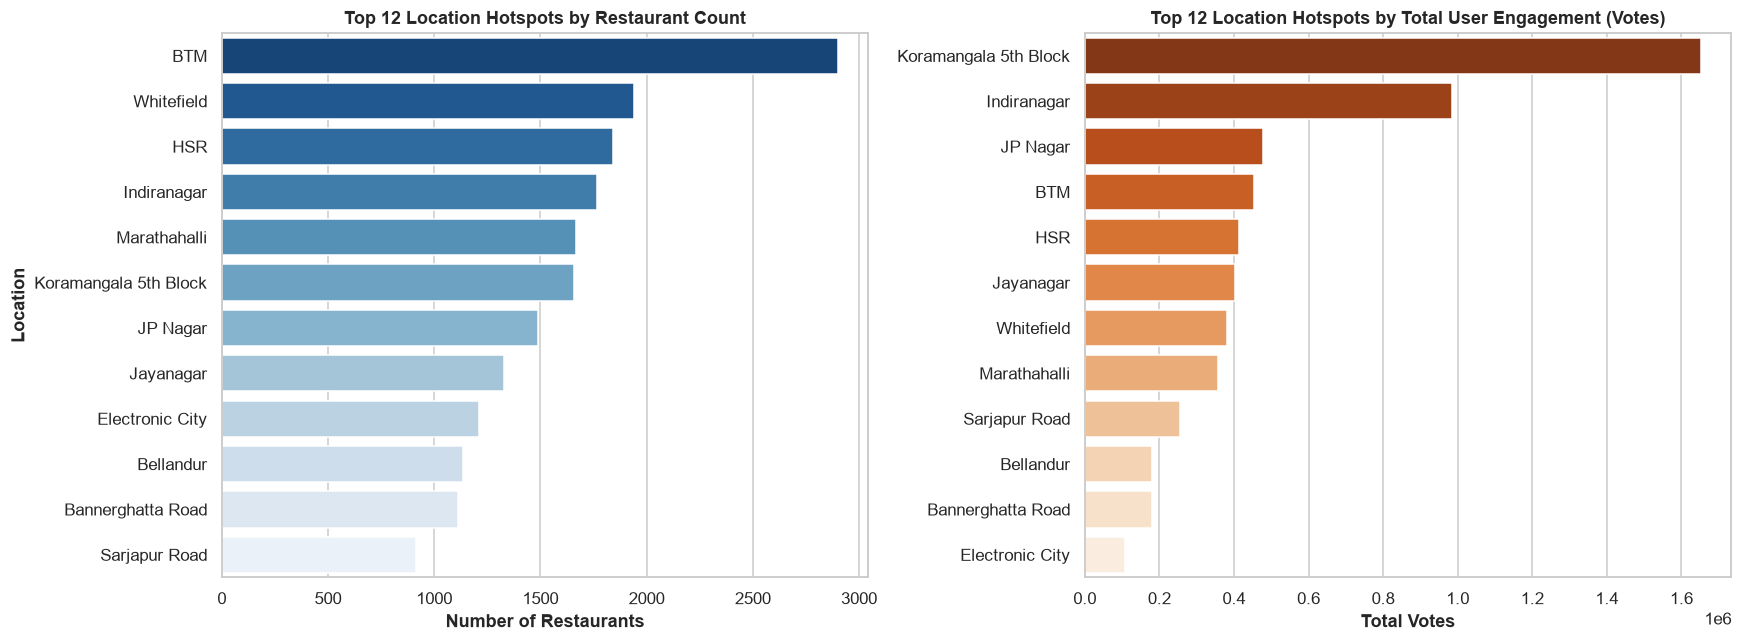

Saved visualization to 'images/location_hotspots.png'


In [5]:
# B. Location Hotspots
location_stats = df.groupby('location').agg(
    restaurant_count=('name', 'count'),
    avg_rating=('rate_num', 'mean'),
    total_votes=('votes', 'sum')
).reset_index()

top_locations = location_stats.sort_values(by='restaurant_count', ascending=False).head(12)

# Plot Top Location Hotspots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_locations, x='restaurant_count', y='location', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 12 Location Hotspots by Restaurant Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Restaurants', fontweight='bold')
axes[0].set_ylabel('Location', fontweight='bold')

sns.barplot(data=top_locations.sort_values(by='total_votes', ascending=False), x='total_votes', y='location', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 12 Location Hotspots by Total User Engagement (Votes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Votes', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('images/location_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/location_hotspots.png'")


C:\Users\user\AppData\Local\Temp\ipykernel_17244\716952181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_rating_df, x='cost_category', y='rate_num', palette='Set2')


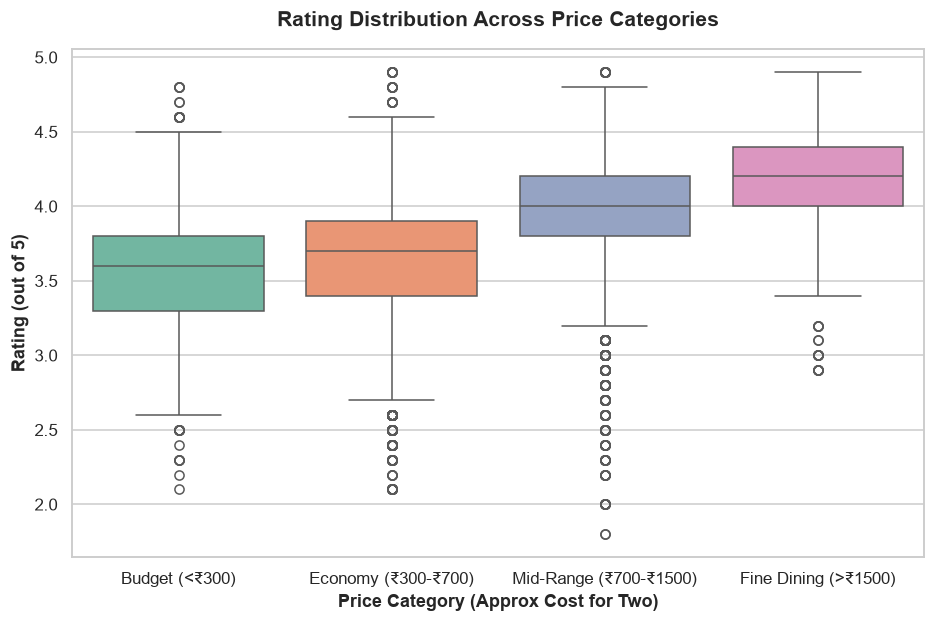

Saved visualization to 'images/price_vs_rating.png'


In [6]:
# C. Price vs Rating
price_rating_df = df.dropna(subset=['approx_cost(for two people)', 'rate_num']).copy()

bins = [0, 300, 700, 1500, 10000]
labels = ['Budget (<₹300)', 'Economy (₹300-₹700)', 'Mid-Range (₹700-₹1500)', 'Fine Dining (>₹1500)']
price_rating_df['cost_category'] = pd.cut(price_rating_df['approx_cost(for two people)'], bins=bins, labels=labels)

# Boxplot: Price Category vs Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=price_rating_df, x='cost_category', y='rate_num', palette='Set2')
plt.title('Rating Distribution Across Price Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price Category (Approx Cost for Two)', fontweight='bold')
plt.ylabel('Rating (out of 5)', fontweight='bold')
plt.savefig('images/price_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/price_vs_rating.png'")


## 3. Build Visualizations
- **Heatmaps**:
  1. Correlation matrix heatmap for numerical and encoded variables (`rate`, `approx_cost`, `votes`, `online_order`, `book_table`).
  2. Pivot table heatmap comparing Top Locations vs Listed Service Types.
- **Wordclouds**:
  1. Wordcloud for Popular Cuisines.
  2. Wordcloud for Popular Dishes (`dish_liked`).


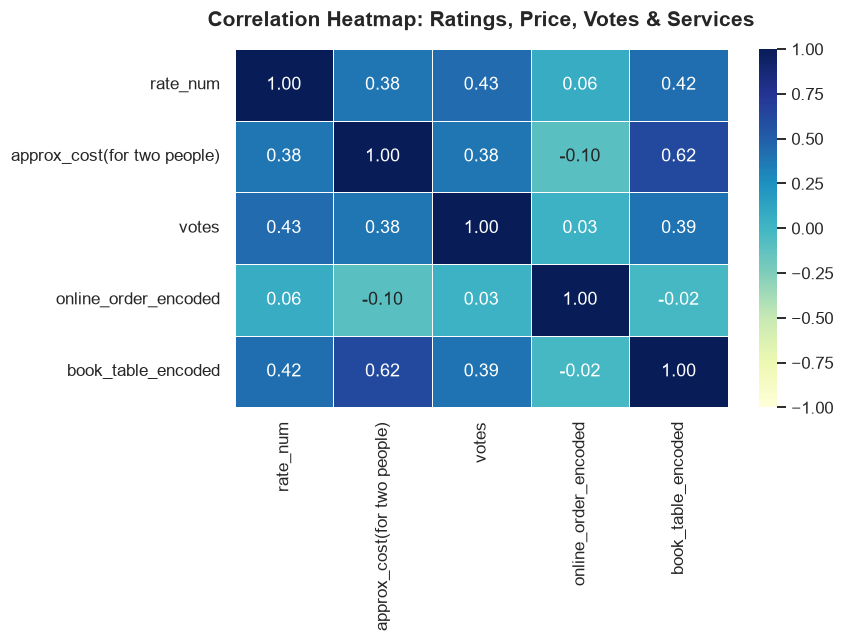

Saved visualization to 'images/correlation_heatmap.png'


In [7]:
# A. Correlation Heatmap
corr_df = df.copy()
corr_df['online_order_encoded'] = corr_df['online_order'].map({'Yes': 1, 'No': 0})
corr_df['book_table_encoded'] = corr_df['book_table'].map({'Yes': 1, 'No': 0})

num_cols = ['rate_num', 'approx_cost(for two people)', 'votes', 'online_order_encoded', 'book_table_encoded']
corr_matrix = corr_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='YlGnBu', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap: Ratings, Price, Votes & Services', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/correlation_heatmap.png'")


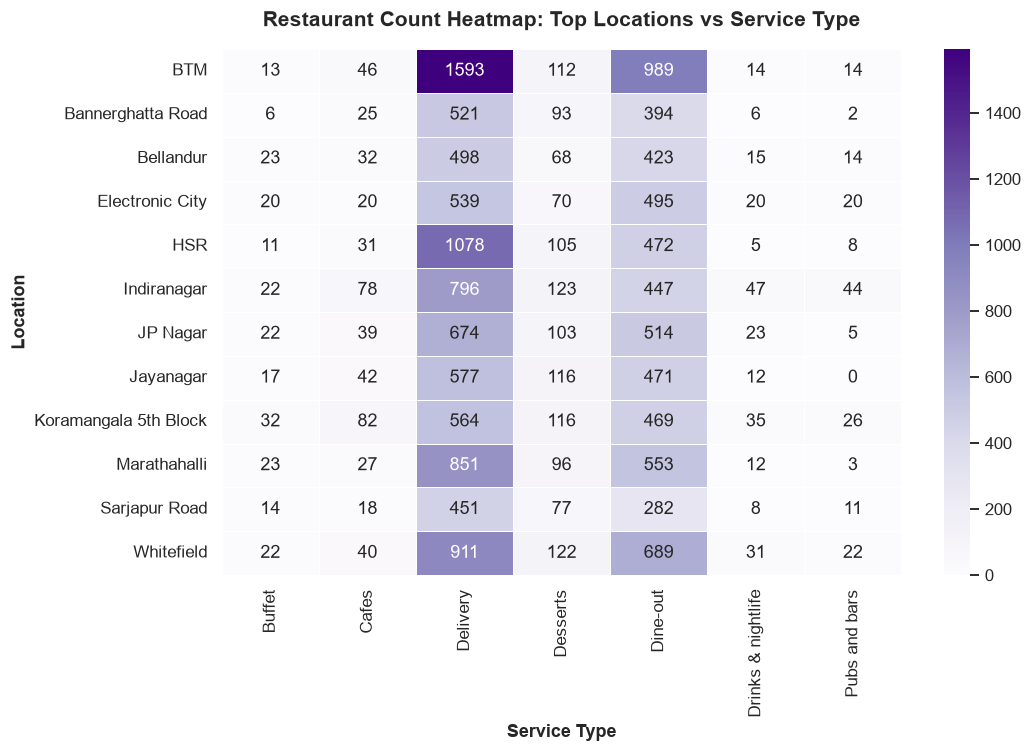

Saved visualization to 'images/location_service_heatmap.png'


In [8]:
# B. Location vs Service Type Heatmap
top_loc_names = top_locations['location'].tolist()
heatmap_data = df[df['location'].isin(top_loc_names)].pivot_table(
    index='location', 
    columns='listed_in(type)', 
    values='name', 
    aggfunc='count', 
    fill_value=0
)

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap='Purples', linewidths=0.5)
plt.title('Restaurant Count Heatmap: Top Locations vs Service Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Service Type', fontweight='bold')
plt.ylabel('Location', fontweight='bold')
plt.tight_layout()
plt.savefig('images/location_service_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/location_service_heatmap.png'")


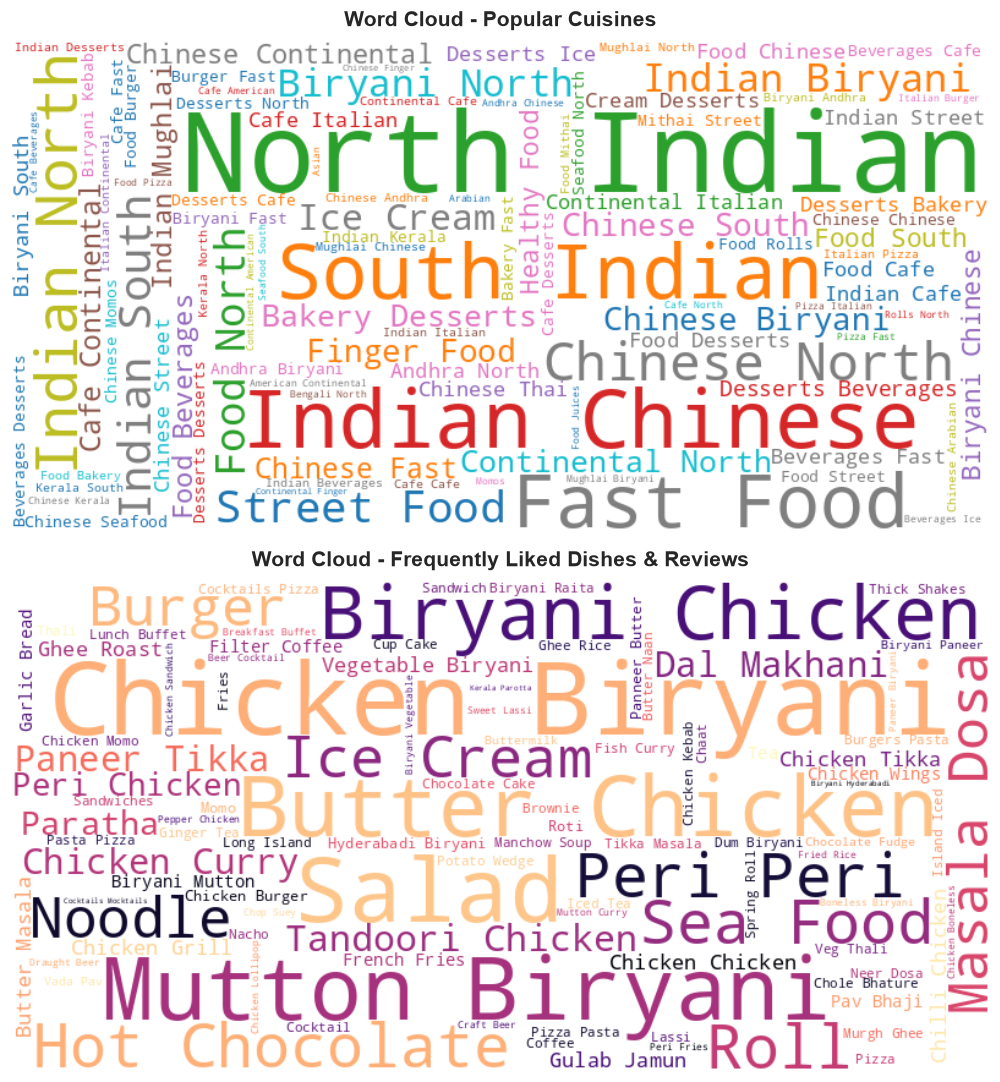

Saved visualization to 'images/wordcloud_cuisines_dishes.png'


In [9]:
# C. Wordclouds for Popular Cuisines & Dishes Liked
cuisines_text = ' '.join(df['cuisines'].dropna().tolist())
wc_cuisines = WordCloud(width=800, height=400, background_color='white', colormap='tab10', max_words=100).generate(cuisines_text)

dishes_text = ' '.join(df['dish_liked'].dropna().tolist())
wc_dishes = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=100).generate(dishes_text)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].imshow(wc_cuisines, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Popular Cuisines', fontsize=14, fontweight='bold', pad=10)

axes[1].imshow(wc_dishes, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Frequently Liked Dishes & Reviews', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('images/wordcloud_cuisines_dishes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/wordcloud_cuisines_dishes.png'")


## 4. Machine Learning Model: Restaurant Rating Predictor
- Build and train a Random Forest Regression model to predict restaurant ratings based on price, votes, location, service type, and table booking availability.
- Evaluate model performance (RMSE, R2 Score).
- Save trained model artifact to `models/zomato_rating_model.pkl`.


Model Performance:
Root Mean Squared Error (RMSE): 0.1462
R² Score: 0.8910
Saved trained model to 'models/zomato_rating_model.pkl'


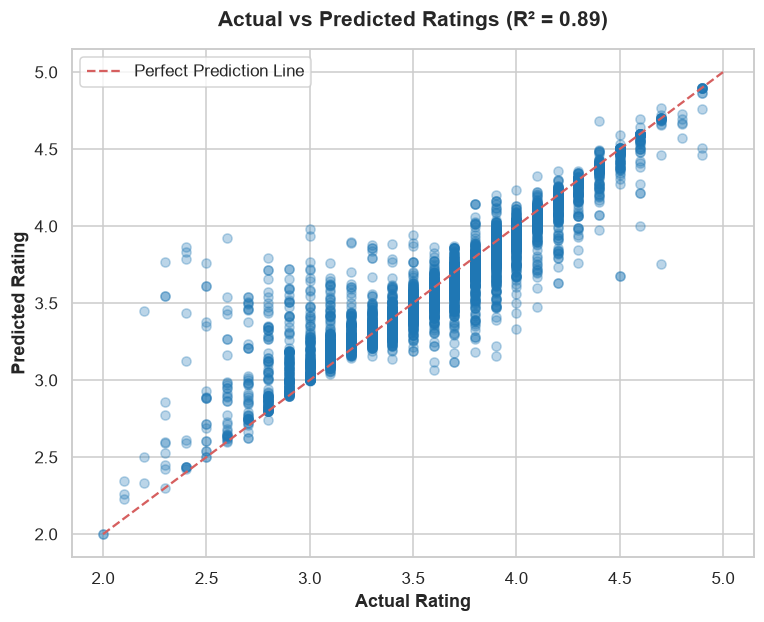

Saved visualization to 'images/actual_vs_predicted_rating.png'


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare dataset for modelling
model_data = df.dropna(subset=['rate_num', 'approx_cost(for two people)', 'votes', 'location', 'rest_type', 'cuisines']).copy()
model_data['online_order_enc'] = (model_data['online_order'] == 'Yes').astype(int)
model_data['book_table_enc'] = (model_data['book_table'] == 'Yes').astype(int)

# Frequency encoding for categoricals
for col in ['location', 'rest_type', 'cuisines']:
    freq = model_data[col].value_counts().to_dict()
    model_data[col + '_freq'] = model_data[col].map(freq)

features = ['approx_cost(for two people)', 'votes', 'online_order_enc', 'book_table_enc', 'location_freq', 'rest_type_freq', 'cuisines_freq']
X = model_data[features]
y = model_data['rate_num']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Save Model Artifact
joblib.dump(rf_model, 'models/zomato_rating_model.pkl')
print("Saved trained model to 'models/zomato_rating_model.pkl'")

# Scatter plot: Actual vs Predicted Ratings
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='tab:blue')
plt.plot([2.0, 5.0], [2.0, 5.0], 'r--', label='Perfect Prediction Line')
plt.xlabel('Actual Rating', fontweight='bold')
plt.ylabel('Predicted Rating', fontweight='bold')
plt.title(f'Actual vs Predicted Ratings (R² = {r2:.2f})', fontsize=14, fontweight='bold', pad=15)
plt.legend()
plt.savefig('images/actual_vs_predicted_rating.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved visualization to 'images/actual_vs_predicted_rating.png'")


## 5. Recommendations for Alfido Tech Style Platform

Based on our exploratory data analysis and predictive modeling, here are 5 actionable strategic recommendations for an **Alfido Tech** food-discovery and delivery platform:

1. **Strategic Restaurant & Location Partnerships**:
   - **Insight:** Hotspots like *BTM*, *Koramangala 5th Block*, and *Indiranagar* account for the highest concentration of restaurants and customer votes.
   - **Recommendation:** Focus initial merchant acquisition and partnership onboarding campaigns in these key location hubs to capture maximum order volume and high active user density.

2. **Curated Content & Theme-Based Discovery**:
   - **Insight:** Dish liked analysis highlights overwhelming popularity for items like *Biryani*, *Pasta*, *Burgers*, *Mocktails*, and *Desserts*.
   - **Recommendation:** Implement theme-based content collections on the platform (e.g., "Best Biryani Spots", "Late-Night Dessert Cravings") to drive user engagement, increase app session time, and boost click-through rates.

3. **Optimized Pricing Tier & Promotion Targeting**:
   - **Insight:** Restaurants in the *Economy (₹300–₹700)* price range represent the majority of customer orders, while *Mid-Range & Fine Dining (>₹700)* enjoy significantly higher average ratings (3.9–4.2 stars).
   - **Recommendation:** Offer tailored commission structures—competitive low rates for budget/economy listings to maintain volume, alongside premium badge placements for higher-end dining listings to maximize platform revenue.

4. **Integrated Table Booking & Digital Pre-Ordering**:
   - **Insight:** Table booking (`book_table = Yes`) strongly correlates with higher ratings (correlation coefficient ~0.40+) and premium dining costs.
   - **Recommendation:** Integrate seamless online table reservation and pre-ordering features into the Alfido Tech platform for dine-in venues to create an end-to-end dining ecosystem.

5. **Hyper-Local Expansion into Underserved Niche Cuisines**:
   - **Insight:** High-rating niche cuisines (such as *Continental*, *Italian*, *Mexican*, and *Asian Fusion*) show strong rating demand but fewer outlets compared to North Indian / Chinese.
   - **Recommendation:** Use platform data to advise partner cloud kitchens and restaurant chains on expanding niche cuisine offerings into high-density residential sectors with low competition.
